In [36]:
import pandas as pd

df = pd.read_csv("airbnb_data.csv")
df.head()

/var/folders/yr/rc7j6wgn1v7gg0h_hdxxl9r00000gn/T/ipykernel_13139/4249778575.py:3: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("airbnb_data.csv")


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,country code,instant_bookable,cancellation_policy,room type,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,US,False,strict,Private room,2020.0,$966,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,US,False,moderate,Entire home/apt,2007.0,$142,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,US,True,flexible,Private room,2005.0,$620,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,US,True,moderate,Entire home/apt,2005.0,$368,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,US,False,moderate,Entire home/apt,2009.0,$204,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [37]:
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        print(f"{col} is numerical")
    else:
        print(f"{col} is categorical")

id is numerical
NAME is categorical
host id is numerical
host_identity_verified is categorical
host name is categorical
neighbourhood group is categorical
neighbourhood is categorical
lat is numerical
long is numerical
country is categorical
country code is categorical
instant_bookable is categorical
cancellation_policy is categorical
room type is categorical
Construction year is numerical
price is categorical
service fee is categorical
minimum nights is numerical
number of reviews is numerical
last review is categorical
reviews per month is numerical
review rate number is numerical
calculated host listings count is numerical
availability 365 is numerical
house_rules is categorical
license is categorical


In [38]:
col_num = df.shape[1]
row_num = df.shape[0]
print(f"Dataframe has {row_num} rows and {col_num} columns.")
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        print(f"{col}: numerical")
        print(f"\tNulls: {df[col].isnull().sum()}")
        print("Mean:", df[col].mean())
        print("Median:", df[col].median())
        print("Std:", df[col].std())
    else:
        print(f"{col}: categorical")
        print(f"\tNulls: {df[col].isnull().sum()}")
        print(f"\tUnique: {df[col].nunique()}")
        if df[col].nunique() < 10:
            print("\tValues:", df[col].unique())
        

Dataframe has 102599 rows and 26 columns.
id: numerical
	Nulls: 0
Mean: 29146234.522129845
Median: 29136603.0
Std: 16257505.607308906
NAME: categorical
	Nulls: 250
	Unique: 61281
host id: numerical
	Nulls: 0
Mean: 49254111474.32867
Median: 49117739352.0
Std: 28538996644.374817
host_identity_verified: categorical
	Nulls: 289
	Unique: 2
	Values: ['unconfirmed' 'verified' nan]
host name: categorical
	Nulls: 406
	Unique: 13190
neighbourhood group: categorical
	Nulls: 29
	Unique: 7
	Values: ['Brooklyn' 'Manhattan' 'brookln' 'manhatan' 'Queens' nan 'Staten Island'
 'Bronx']
neighbourhood: categorical
	Nulls: 16
	Unique: 224
lat: numerical
	Nulls: 8
Mean: 40.728093870371374
Median: 40.72229
Std: 0.055856516027438886
long: numerical
	Nulls: 8
Mean: -73.94964395581123
Median: -73.95444
Std: 0.04952126420255945
country: categorical
	Nulls: 532
	Unique: 1
	Values: ['United States' nan]
country code: categorical
	Nulls: 131
	Unique: 1
	Values: ['US' nan]
instant_bookable: categorical
	Nulls: 105
	

In [39]:
print(df['number of reviews'].skew())

3.839396215317322


In [40]:
print(df['number of reviews'].kurt())

25.029862183557565


In [41]:
import matplotlib.pyplot as plt
import scipy.stats as stats

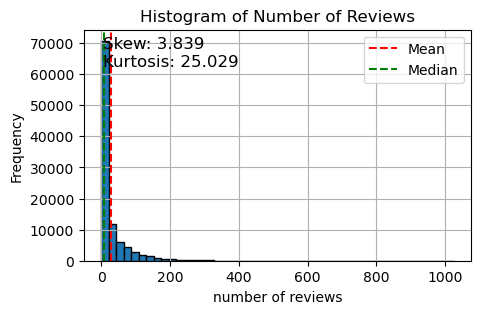

In [42]:
plt.figure(figsize=(5,3))
numrev = df["number of reviews"]
bins = round(numrev.count() ** (1/3))
plt.hist(x=numrev, bins=bins, edgecolor="black")
plt.xlabel("number of reviews")
plt.ylabel("Frequency")
plt.title("Histogram of Number of Reviews")
plt.grid(True)
sk = stats.skew(numrev, nan_policy="omit")
kurt = stats.kurtosis(numrev, nan_policy="omit")
text = f"Skew: {sk:.3f}\nKurtosis: {kurt:.3f}"
plt.text(
    x=0.05, 
    y=0.90, 
    s=text, 
    va="center", 
    fontsize=12, 
    transform=plt.gca().transAxes)
plt.axvline(x=numrev.mean(), color="r", linestyle="--", label="Mean")
plt.axvline(x=numrev.median(), color="g", linestyle="--", label="Median")
plt.legend()
plt.show()

In [43]:
import seaborn as sns

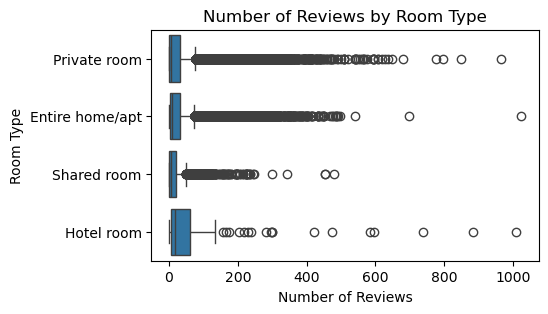

In [45]:
plt.figure(figsize=(5,3))

sns.boxplot(data=df, x="number of reviews", y="room type")

plt.xlabel("Number of Reviews")
plt.ylabel("Room Type")
plt.title("Number of Reviews by Room Type")

plt.show()

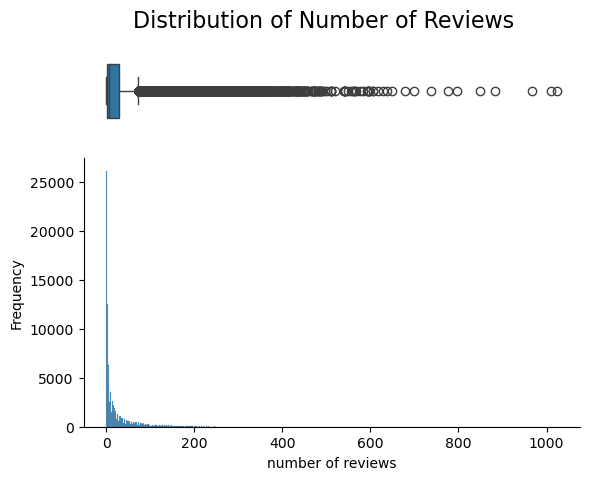

In [46]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, height_ratios=[2, 8])
hist = sns.histplot(data=df, x="number of reviews", ax=ax2)
box = sns.boxplot(data=df, x="number of reviews", ax=ax1)
box.set(xlabel="") 
ax1.spines["bottom"].set_visible(False)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.spines["left"].set_visible(False)
ax1.set(yticks=[])
ax1.set(xticks=[])
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.set_ylabel("Frequency")
fig.suptitle("Distribution of Number of Reviews", fontsize=16)
plt.show()